<a href="https://colab.research.google.com/github/SerraGuney/Optimized-Transfer-Learning-for-Multi-Class-Plant-Disease-Classification/blob/main/Optimized_Transfer_Learning_for_Multi_Class_Plant_Disease_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Veri setini colab dosyasına indirme

# Bu çalışmanın amacı, PlantVillage veri setindeki çok sınıflı yaprak görüntülerini kullanarak, 38 farklı sınıfa ait bitki hastalıklarını derin öğrenme ve transfer learning yöntemleri ile doğru şekilde sınıflandırmaktır.

Mobilenet ile trasfer learning gerçekleştircez.çünkü daha az karmaşık ve kullanması daha kolaydır.

**1. Veri Yükleme ve data augmentation**

In [1]:
from google.colab import userdata
import os

# 1. Kaggle API anahtarlarını yükle
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# 2. Veri indir ve ayıkla
if not os.path.exists('/content/data/color'):
    print(" İndirme başlıyor...")
    !kaggle datasets download -d abdallahalidev/plantvillage-dataset

    print(" Zip açılıyor...")
    !unzip -q plantvillage-dataset.zip -d /content/data

    # EKRAN GÖRÜNTÜSÜNDEKİ GERÇEK YOL: /content/data/plantvillage dataset/color
    # Not: Klasör isminde boşluk olduğu için tırnak işareti (" ") kullandık.
    print(" Klasörler taşınıyor...")
    !mv "/content/data/plantvillage dataset/color" /content/data/

    # Gereksizleri temizle
    !rm -rf "/content/data/plantvillage dataset"
    !rm plantvillage-dataset.zip

    print(" İşlem tamam! /content/data/color klasörü hazır.")
else:
    print(" Veriler zaten mevcut.")

 İndirme başlıyor...
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
 99% 2.03G/2.04G [00:14<00:00, 71.6MB/s]
100% 2.04G/2.04G [00:15<00:00, 138MB/s] 
 Zip açılıyor...
 Klasörler taşınıyor...
 İşlem tamam! /content/data/color klasörü hazır.


In [ ]:
import os

# Data klasörünün içinde gerçekten ne var?
print("Data içindekiler:", os.listdir('/content/data'))

# Eğer boşsa, bir de ana dizine bakalım, belki yanlış yere açılmıştır
print("Ana dizin içindekiler:", os.listdir('/content'))


** Kütüphane Bilgilendirmeleri**
**torch:** Temel kütüphanedir. GPU destekli çok boyutlu dizileri (tensor) ve matematiksel işlemleri yönetir.

**torch.nn:** Sinir ağı katmanlarını (Convolution, Linear, Dropout vb.) ve kayıp fonksiyonlarını (Loss functions) oluşturmak için kullanılır.

**torch.optim:** Modelin parametrelerini (ağırlıklarını) güncellemek için kullanılan algoritmaları (Adam, SGD vb.) barındırır.

**torchvision.transforms:** Görüntüleri Tensor formatına çevirme, yeniden boyutlandırma ve normalizasyon gibi ön işleme işlemlerini yapar.

**torchvision.datasets:** Dosya sistemindeki görüntüleri otomatik olarak etiketleyip veri kümesi (dataset) nesnesine dönüştürür.

**torchvision.models:** Önceden eğitilmiş (Pre-trained) mimarileri (ResNet50, MobileNetV2 vb.) projeye dahil eder.

**DataLoader: **Veri kümesini bellek yönetimine uygun şekilde küçük gruplara (batch) böler ve karıştırarak (shuffle) modele sunar.

**tqdm:** Döngülerin (eğitim ve test aşamaları) ilerleme durumunu ve süresini konsolda görselleştirir.

**matplotlib.pyplot:**Eğitim sırasındaki hata ve doğruluk oranlarını grafik olarak raporlamak için kullanılır.

**seaborn:** Matplotlib tabanlıdır; karmaşıklık matrisi (confusion matrix) gibi istatistiksel verileri daha okunabilir şekilde görselleştirir.

**sklearn.metrics:** Modelin performansını ölçmek için kesinlik (precision), duyarlılık (recall) ve F1 skoru gibi metrikleri hesaplar.


In [8]:
import torch
import torch.nn as nn # sinir ağı katmanları için
import torch.optim as optim # sinir ağındaki optimizasyon algoritmaları için
import torchvision.transforms as transforms # görüntü dönüşümleri için (data augmentataion)
import torchvision.datasets as datasets # görüntü veri kümeleri için
import torchvision.models as models # önceden eğitilmiş modelleri yüklemek için(mobilenet,...)
from torch.utils.data import DataLoader #batchler oluşturur.
from tqdm import tqdm # eğitim sürecini izlemek için kullancağımız bir ilerleme cubugu
import matplotlib.pyplot as plt # görselleştirme için
import seaborn as sns #confuxion matris için
from sklearn.metrics import confusion_matrix, classification_report #confuxion matris için
import numpy as np


**veri dönüşümü**
1.   klasik dönüşümler:normalizasyon, tensor dönüşümü
2.   mobilnet e uygun giris boyutunun ayarlanması
3.   data augmentation





In [9]:
transform_train=transforms.Compose([
    transforms.Resize((224,224)), #mobile net input size yazmamız lazım.
    transforms.RandomHorizontalFlip(), # görüntüleri yatay çevirerek veri arttırımı.
    transforms.RandomRotation(10), # görüntüyü rastgele 10 dereceye kadar döndürür.
    transforms.ColorJitter(brightness=0.2, contrast=0.2,saturation=0.2, hue=0.1) , # aynı görüntünün renk varyansolarını sağlar.
    transforms.ToTensor(),#goruntüleri tensore(C,H,W) ve piksel değerlerini 0–1 aralığına çevir.
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) #piksel değerlerini normalize eder.
])
#test veri setinde augmentation uygulanmaz(horizontal,rotation,..)
transform_test=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

veri setini split etmek.

Toplam resim sayısı ~54.305 (38013 + 8145 + 8147 ≈ 54.305).

Eğitim: %70 → 38.013

Doğrulama: %15 → 8.145

Test: %15 → 8.147

In [10]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader, random_split, Dataset

# 1. Ana veri kümesini oku (Transformsız)
full_dataset = datasets.ImageFolder(root='/content/data/color')

# 2. Boyutları hesapla
total_count = len(full_dataset)
train_count = int(0.7 * total_count)
val_count = int(0.15 * total_count)
test_count = total_count - train_count - val_count

# 3. Sadece indeksleri böl
train_indices, val_indices, test_indices = random_split(
    range(total_count),
    [train_count, val_count, test_count],
    generator=torch.Generator().manual_seed(42)
)

# 4. Kendi transformunu taşıyan özel bir sınıf (Wrapper)
class ApplyTransform(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# 5. Parçaları oluştur ve transformları ata
# Burada full_dataset'i indekslere göre böldükten sonra transformları uyguluyoruz
train_dataset = ApplyTransform(torch.utils.data.Subset(full_dataset, train_indices), transform=transform_train)
val_dataset = ApplyTransform(torch.utils.data.Subset(full_dataset, val_indices), transform=transform_test)
test_dataset = ApplyTransform(torch.utils.data.Subset(full_dataset, test_indices), transform=transform_test)

print(f" Bölme bitti ve transformlar ayrıştırıldı!")
print(f"Eğitim: {len(train_dataset)} | Doğrulama: {len(val_dataset)} | Test: {len(test_dataset)}")

 Bölme bitti ve transformlar ayrıştırıldı!
Eğitim: 38013 | Doğrulama: 8145 | Test: 8147


Veri seti hakkında bilgi edinmek için rastgele 5 örnek seçip görselleştirme.


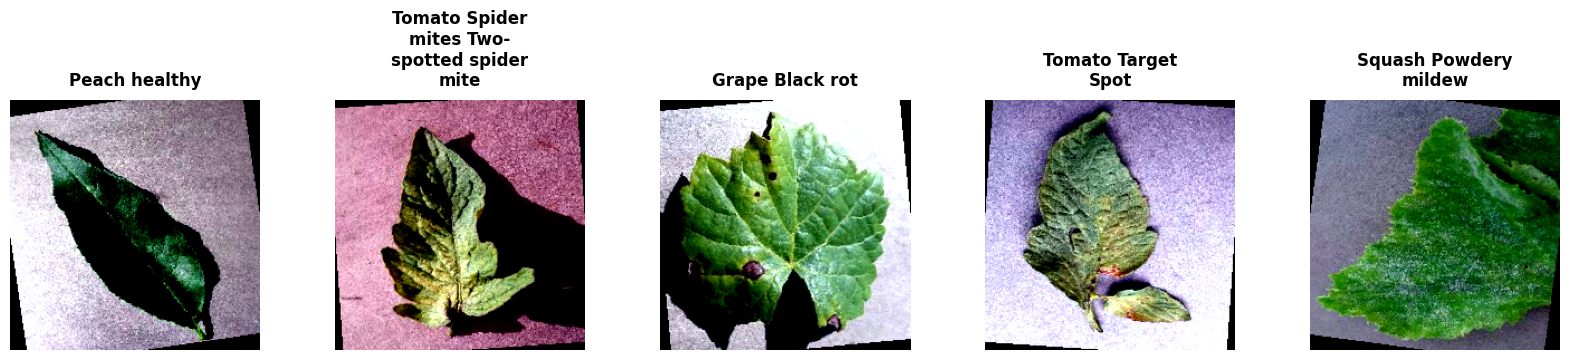

In [11]:
import torch
import matplotlib.pyplot as plt
import textwrap

# 1. Sınıf isimlerini al
class_names = full_dataset.classes

# 2. Rastgele 5 indeks seç
indices = torch.randint(len(train_dataset), (5,))
samples = [train_dataset[i] for i in indices]

# 3. Görselleştirme
fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for i, (image, label) in enumerate(samples):
    # Tensor'dan (C, H, W) -> Numpy'a (H, W, C) dönüşümü
    image = image.numpy().transpose((1, 2, 0))

    # Normalizasyonu geri al (Normalize işlemi: (x-0.5)/0.5 yapmıştık, şimdi geri çeviriyoruz)
    image = (image * 0.5) + 0.5
    image = image.clip(0, 1) # Piksel değerlerinin 0-1 arasında olduğundan emin ol

    axes[i].imshow(image)

    # İsim Formatlama: Alt tireleri boşluğa çevir ve 15 karakterde bir böl
    raw_name = class_names[label].replace("___", " ").replace("_", " ")
    wrapped_name = "\n".join(textwrap.wrap(raw_name, width=15))

    axes[i].set_title(wrapped_name, fontsize=12, pad=10, fontweight='semibold')
    axes[i].axis('off')

plt.subplots_adjust(wspace=0.3)
plt.show()

In [22]:
#data loader

# shuffle=True:veri setindeki resimlerin sırasını rastgele karıştırır.


# Doğrulama ve Test için Shuffle=False (Sadece ölçüm yapıyoruz, karıştırmaya gerek yok)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,       # 32'den 64'e çıkardık
    shuffle=True,
    num_workers=2,       # Paralel veri yükleme ekledik
    pin_memory=True      # GPU'ya veri transferini hızlandırır
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

CNN modeli iki ana bölümden oluşur:

1. Feature extractor (özellik çıkarıcı)
Resimden özellikleri çıkarır.

2. Classifier (sınıflandırıcı)
Bu özelliklere bakıp hangi sınıf olduğunu tahmin eder.

Sen burada classifier kısmına erişiyorsun.

model.classifier

mesela şöyle olabilir:

Sequential(

  (0): Dropout
  (1): Linear(in_features=1280, out_features=1000)
  
)

Burada:

in_features = 1280

yani modele 1280 özellik geliyor.

Kod bunu alıyor:

num_ftrs = 1280
 Bu satır ne yapıyor?
model.classifier[1] = nn.Linear(num_ftrs, 38)

Burada son katmanı değiştiriyorsun.

Eskisi genelde şöyle olur:

Linear(1280, 1000)

Çünkü ImageNet modeli 1000 sınıf için eğitilmiştir.

Ama senin veri setinde:

38 sınıf var

O yüzden değiştiriyorsun:

Linear(1280, 38)

yani:

1280 özellik → 38 sınıf

 Görsel mantık
Resim
   ↓
CNN Feature Extractor
   ↓
1280 özellik
   ↓
Linear Layer
   ↓
38 sınıf

**2. Transfer learning tanımlama, Feature Extraction ve fine tuning ve model kaydetme**

In [23]:

# GPU varsa GPU, yoksa CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Feature Extraction ---
def get_feature_extraction_model(num_classes=38):
    model = models.mobilenet_v2(weights='DEFAULT')

    # tüm feature extractor'ı dondur
    for param in model.features.parameters():
        param.requires_grad = False

    # classifier'ı kendi sınıf sayına göre değiştir
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, num_classes)

    return model.to(device)

# --- Full Fine-Tuning ---
def get_fine_tuning_model(num_classes=38):
    model = models.mobilenet_v2(weights='DEFAULT')

    # tüm katmanlar eğitilebilir
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, num_classes)

    return model.to(device)

Training

In [25]:
def train_and_evaluate(model, optimizer, criterion, epochs=15, save_name="temp_model.pth", scheduler=None):
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    best_loss = float("inf")
    counter = 0
    patience = 5  # Early stopping için sabır süresi

    for epoch in range(epochs):
        # --- EĞİTİM AŞAMASI ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        loop = tqdm(train_loader, leave=False)
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

            loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
            loop.set_postfix(loss=loss.item())

        # --- DOĞRULAMA (VALIDATION) AŞAMASI ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        # Metrik Hesaplamaları
        t_loss = train_loss / train_total
        v_loss = val_loss / val_total
        t_acc = 100. * train_correct / train_total
        v_acc = 100. * val_correct / val_total

        history['train_loss'].append(t_loss)
        history['test_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['test_acc'].append(v_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {t_loss:.4f} | Train Acc: {t_acc:.2f}% | Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.2f}%")

        # --- SCHEDULER ADIMI ---
        if scheduler is not None:
            scheduler.step(v_loss)
            current_lr = optimizer.param_groups[0]['lr']
            print(f" > Mevcut Öğrenme Hızı: {current_lr:.6f}")

        # --- EN İYİ MODELİ KAYDETME VE EARLY STOPPING ---
        if v_loss < best_loss:
            best_loss = v_loss
            counter = 0
            torch.save(model.state_dict(), save_name)
            print(f"  Yeni en iyi model kaydedildi: {save_name}")
        else:
            counter += 1

        if counter >= patience:
            print(f"  Early stopping çalıştı! {epoch+1}. epoch'ta durduruldu.")
            break

    return history

Model ve optimizer oluşturma

In [ ]:
criterion = nn.CrossEntropyLoss()
overall_best_acc = 0.0

# --- 1. DENEY: FEATURE EXTRACTION ---
print("\n" + "="*40)
print("--- 1. DENEY: FEATURE EXTRACTION BAŞLIYOR ---")
print("="*40)

model_fe = get_feature_extraction_model(num_classes=38)
optimizer_fe = optim.Adam(model_fe.classifier[1].parameters(), lr=0.001)

# Scheduler: 2 epoch boyunca val_loss düşmezse hızı %10'una indir
scheduler_fe = optim.lr_scheduler.ReduceLROnPlateau(optimizer_fe, mode='min', factor=0.1, patience=2)

fe_history = train_and_evaluate(model_fe, optimizer_fe, criterion, epochs=10,
                               save_name="best_fe.pth", scheduler=scheduler_fe)

# --- 2. DENEY: FULL FINE-TUNING ---
print("\n" + "="*40)
print("--- 2. DENEY: FULL FINE-TUNING BAŞLIYOR ---")
print("="*40)

model_ft = get_fine_tuning_model(num_classes=38)
optimizer_ft = optim.Adam(model_ft.parameters(), lr=0.0001)

# Scheduler: 3 epoch boyunca val_loss düşmezse hızı %10'una indir
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode='min', factor=0.1, patience=3)

ft_history = train_and_evaluate(model_ft, optimizer_ft, criterion, epochs=15,
                               save_name="best_ft.pth", scheduler=scheduler_ft)

# --- FİNAL KARŞILAŞTIRMA ---
fe_max = max(fe_history['test_acc'])
ft_max = max(ft_history['test_acc'])

print("\n" + " SUMMARY ".center(40, "="))
print(f"FE (Feature Extraction) En İyi Başarı: %{fe_max:.2f}")
print(f"FT (Full Fine-Tuning) En İyi Başarı: %{ft_max:.2f}")

if ft_max > fe_max:
    print(f"\n Fine-Tuning! \nKullanılacak dosya: 'best_ft.pth'")
else:
    print(f"\n  Feature Extraction! \nKullanılacak dosya: 'best_fe.pth'")


--- 1. DENEY: FEATURE EXTRACTION BAŞLIYOR ---


Epoch [1/10] | Train Loss: 0.8965 | Train Acc: 80.98% | Val Loss: 0.3080 | Val Acc: 93.47%
 > Mevcut Öğrenme Hızı: 0.001000
  Yeni en iyi model kaydedildi: best_fe.pth


Epoch [2/10] | Train Loss: 0.3367 | Train Acc: 91.95% | Val Loss: 0.2091 | Val Acc: 94.48%
 > Mevcut Öğrenme Hızı: 0.001000
  Yeni en iyi model kaydedildi: best_fe.pth


Epoch [3/10] | Train Loss: 0.2560 | Train Acc: 93.28% | Val Loss: 0.1638 | Val Acc: 95.46%
 > Mevcut Öğrenme Hızı: 0.001000
  Yeni en iyi model kaydedildi: best_fe.pth


Epoch [4/10] | Train Loss: 0.2236 | Train Acc: 93.71% | Val Loss: 0.1427 | Val Acc: 96.06%
 > Mevcut Öğrenme Hızı: 0.001000
  Yeni en iyi model kaydedildi: best_fe.pth


...

Epoch [7/15] | Train Loss: 0.0168 | Train Acc: 99.49% | Val Loss: 0.0164 | Val Acc: 99.48%
 > Mevcut Öğrenme Hızı: 0.000100


Epoch [8/15] | Train Loss: 0.0145 | Train Acc: 99.55% | Val Loss: 0.0141 | Val Acc: 99.67%
 > Mevcut Öğrenme Hızı: 0.000100


Epoch [9/15] | Train Loss: 0.0120 | Train Acc: 99.66% | Val Loss: 0.0158 | Val Acc: 99.56%
 > Mevcut Öğrenme Hızı: 0.000100


Epoch [10/15] | Train Loss: 0.0125 | Train Acc: 99.60% | Val Loss: 0.0144 | Val Acc: 99.58%
 > Mevcut Öğrenme Hızı: 0.000010


Epoch [11/15]:  86%|████████▌ | 508/594 [04:51<00:52,  1.63it/s, loss=0.000299]

**3.Sonuçları görselleştirme**

In [ ]:
def visualize_predictions(model, dataloader, title, num_images=5):
    model.eval()
    images_handled = 0
    plt.figure(figsize=(18, 5)) # Biraz genişlettik

    # Sınıf isimlerini ana veri kümesinden güvenli alalım
    current_class_names = full_dataset.classes

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_handled += 1
                ax = plt.subplot(1, num_images, images_handled)
                ax.axis('off')

                # Görseli geri normalize et (Yukarıdaki yeni değerlere göre)
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                plt.imshow(img)

                p_idx = preds[j].item()
                l_idx = labels[j].item()

                # İsimleri index yerine metin olarak yazdıralım (Daha anlaşılır olur)
                p_name = "\n".join(textwrap.wrap(current_class_names[p_idx].replace("_"," "), width=15))
                l_name = "\n".join(textwrap.wrap(current_class_names[l_idx].replace("_"," "), width=15))

                color = "green" if p_idx == l_idx else "red"
                ax.set_title(f"Tahmin: {p_name}\nGerçek: {l_name}", color=color, fontsize=10)

                if images_handled == num_images:
                    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.05)
                    plt.tight_layout()
                    return

In [ ]:
def plot_confusion_matrix(model, dataloader, class_names, title="Confusion Matrix"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Tahmin")
    plt.ylabel("Gerçek")
    plt.title(title, fontsize=16)
    plt.show()

In [ ]:
# Rastgele 5 örnek görselleştir
visualize_predictions(model_fe, val_loader, title="1. Deney: Feature Extraction Sonuçları")
visualize_predictions(model_ft, val_loader, title="2. Deney: Full Fine-Tuning Sonuçları")

# Loss & Accuracy grafikleri
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(fe_history['test_acc'], label='FE Test Acc', marker='o')
plt.plot(ft_history['test_acc'], label='FT Test Acc', marker='s')
plt.title('Test Accuracy Karşılaştırması')
plt.xlabel('Epoch')
plt.ylabel('Başarı (%)')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(fe_history['test_loss'], label='FE Test Loss', marker='o')
plt.plot(ft_history['test_loss'], label='FT Test Loss', marker='s')
plt.title('Test Loss Karşılaştırması')
plt.xlabel('Epoch')
plt.ylabel('Kayıp (Loss)')
plt.legend()
plt.tight_layout()
plt.show()

# Confusion Matrix
actual_class_names = full_dataset.classes # Hata veren satırı bununla değiştir
plot_confusion_matrix(model_fe, val_loader, class_names, title="Feature Extraction Confusion Matrix")
plot_confusion_matrix(model_ft, val_loader, class_names, title="Full Fine-Tuning Confusion Matrix")